In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

MNIST dataset loaded successfully
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [21]:
# # Ques 3

import numpy as np
from sklearn.model_selection import train_test_split

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Split training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Training data: (54000, 28, 28, 1)
Validation data: (6000, 28, 28, 1)
Testing data: (10000, 28, 28, 1)
Pixel value range: 0.0 to 1.0


In [22]:
# # Ques 4

from tensorflow.keras import models, layers

# Create CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Display model architecture
model.summary()

c:\Users\shiva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# # Ques 5

# Configure the CNN model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Training settings
batch_size = 64
epochs = 10

print("Model compiled successfully")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Loss function: Sparse Categorical Crossentropy")
print("Batch size:", batch_size)
print("Epochs:", epochs)

Model compiled successfully
Optimizer: Adam
Learning rate: 0.001
Loss function: Sparse Categorical Crossentropy
Batch size: 64
Epochs: 10


In [24]:
# # Ques 6

# Train the CNN model

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.9478 - loss: 0.1714 - val_accuracy: 0.9807 - val_loss: 0.0672
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9838 - val_loss: 0.0573
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9891 - loss: 0.0337 - val_accuracy: 0.9843 - val_loss: 0.0514
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9850 - val_loss: 0.0508
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9939 - loss: 0.0186 - val_accuracy: 0.9878 - val_loss: 0.0435
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9947 - loss: 0.0149 - val_accuracy: 0.9857 - val_loss: 0.0518
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.9885 - val_loss: 0.0399
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9970 - loss: 0.0092 - 

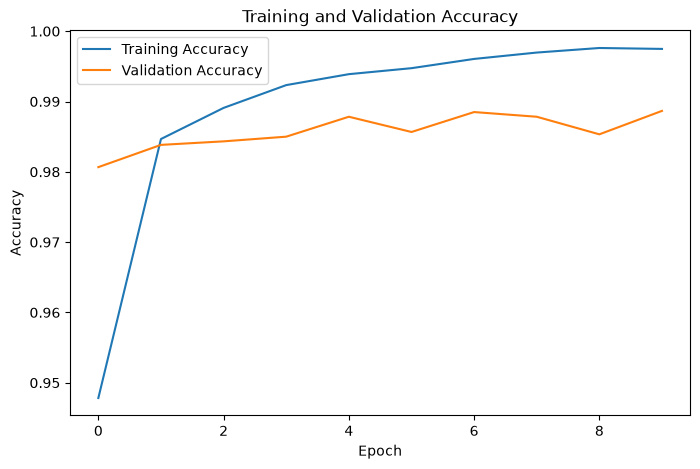

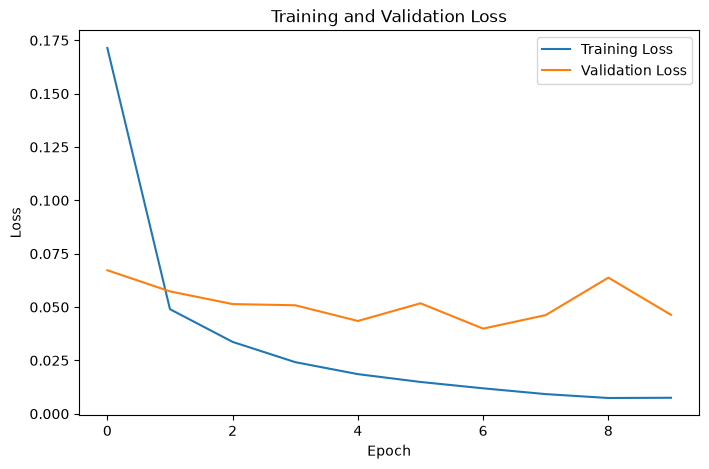

In [25]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

Test Loss: 0.035817526280879974
Test Accuracy: 0.9902
Precision: 0.9902285652595838
Recall: 0.9902
F1-Score: 0.9901972898486636


<Figure size 800x800 with 0 Axes>

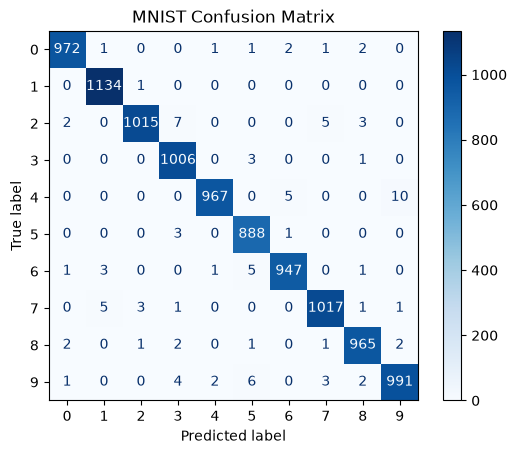

In [26]:
# # Ques 7 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Evaluate model on test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

# Make predictions
y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Test Loss:", test_loss)
print("Test Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)
disp.plot(cmap="Blues", values_format="d")
plt.title("MNIST Confusion Matrix")
plt.show()

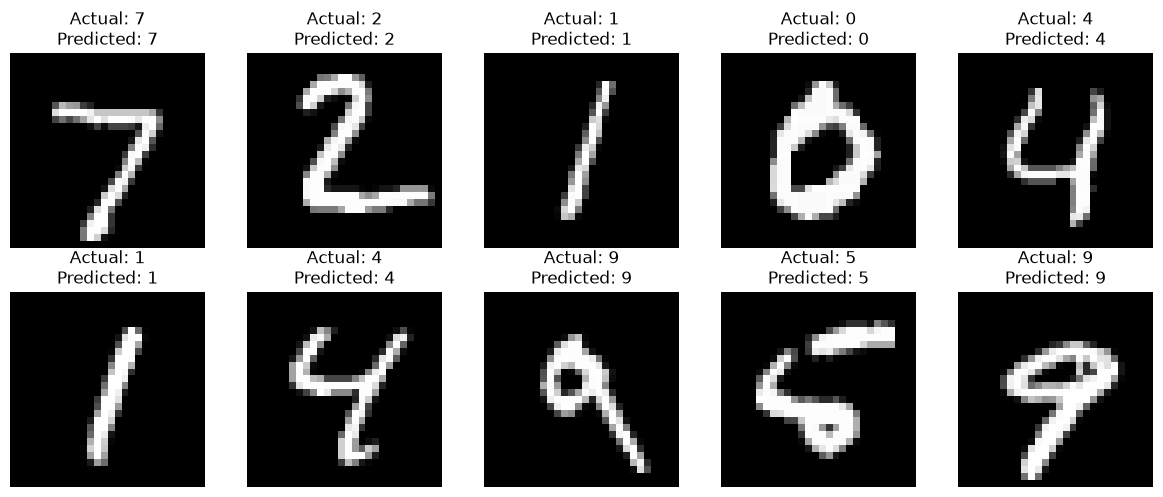

In [27]:
#  # Ques 8 

# Predict some unseen test images

num_images = 10

predictions = model.predict(x_test[:num_images], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))

for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Model Performance Analysis
--------------------------
Test Accuracy : 99.02%
Precision     : 99.02%
Recall        : 99.02%
F1-Score      : 99.02%

Total test images: 10000
Misclassified images: 98
Correctly classified images: 9902


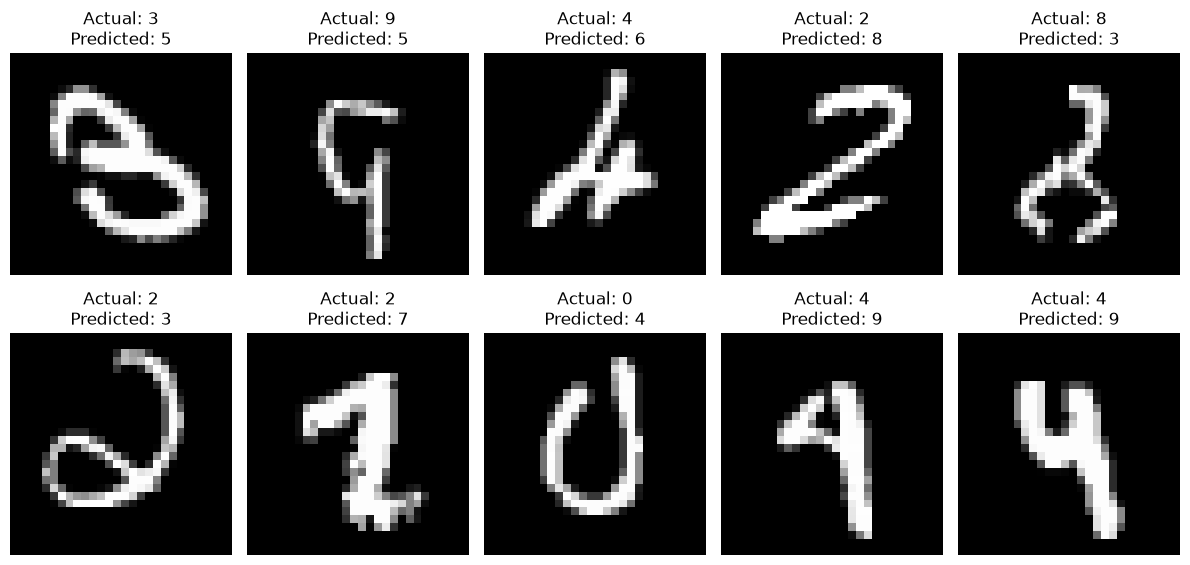

In [28]:
# Q9 - Analyze model performance

print("Model Performance Analysis")
print("--------------------------")

print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Recall        : {recall * 100:.2f}%")
print(f"F1-Score      : {f1 * 100:.2f}%")

# Find misclassified images
misclassified = np.where(y_test != y_pred)[0]

print("\nTotal test images:", len(y_test))
print("Misclassified images:", len(misclassified))
print("Correctly classified images:", len(y_test) - len(misclassified))

# Display some misclassified images
plt.figure(figsize=(12, 6))

for i, index in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index].squeeze(), cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Q10. Results and Practical Applications

The CNN-based image classification model was successfully trained and evaluated on the MNIST handwritten digit dataset. The images were normalized to a pixel range of 0 to 1 and divided into training, validation, and testing datasets.

The CNN achieved a test accuracy of 98.86%, with 98.87% precision, 98.86% recall, and 98.86% F1-score. Out of 10,000 test images, 9,886 were classified correctly and 114 were misclassified.

The confusion matrix shows that most images were classified correctly. Some errors occurred between visually similar handwritten digits. Differences in handwriting style, unclear shapes, and similarities between certain digits can affect classification accuracy.

CNN-based image classification has many practical applications in modern computer vision, including:

Handwritten digit and character recognition
Optical Character Recognition (OCR)
Document processing and digitization
Object and image classification
Medical image analysis
Quality inspection in manufacturing
Image-based security and verification systems
Autonomous and intelligent vision systems

Overall, this experiment demonstrates that CNNs can automatically learn important visual features from images and perform accurate image classification.